<a href="https://colab.research.google.com/github/lessleyH/energy-reliability-systems-/blob/main/ERCOT_2025_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Load ERCOT Data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

import os
import zipfile

In [ ]:
os.listdir('/content/drive/MyDrive/energy-reliability-systems/data')

['Native_Load_2026.zip', 'Native_Load_2025.zip', 'LCD_USW00012918_2025.csv']

In [ ]:
zip_path = '/content/drive/MyDrive/energy-reliability-systems/data/Native_Load_2025.zip'

In [ ]:
import zipfile
import os

extract_path = '/content/ercot_data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted!")
print(os.listdir(extract_path))

Files extracted!
['Native_Load_2025.xlsx']


In [ ]:
import os

os.listdir('/content/ercot_data')

['Native_Load_2025.xlsx']

In [ ]:


file_path = '/content/ercot_data/Native_Load_2025.xlsx'

df = pd.read_excel(file_path)

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,01/01/2025 01:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905
1,01/01/2025 02:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212
2,01/01/2025 03:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847
3,01/01/2025 04:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583
4,01/01/2025 05:00,10332.692971,1585.772017,7026.066195,1425.900669,12307.605237,2975.631819,6298.522746,1301.043053,43253.234707



# 2. Clean Timestamps

In [ ]:
df['Hour Ending'] = df['Hour Ending'].str.replace('24:00', '00:00')
df['Hour Ending'] = df['Hour Ending'].str.replace(' DST', '')

df['Hour Ending'] = pd.to_datetime(df['Hour Ending'])

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,2025-01-01 01:00:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905
1,2025-01-01 02:00:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212
2,2025-01-01 03:00:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847
3,2025-01-01 04:00:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583
4,2025-01-01 05:00:00,10332.692971,1585.772017,7026.066195,1425.900669,12307.605237,2975.631819,6298.522746,1301.043053,43253.234707



# 3. Explore Load Shape

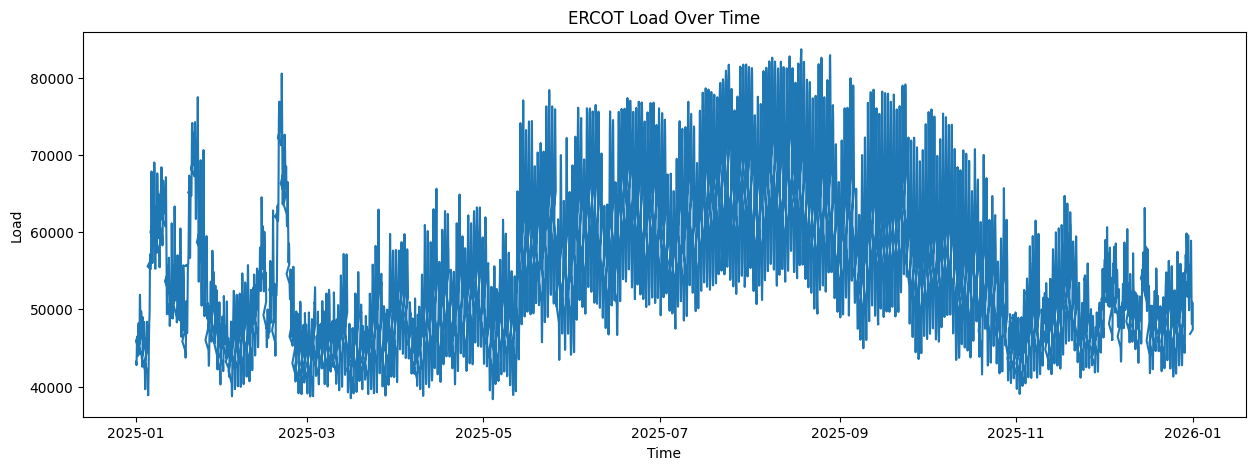

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['ERCOT'])

plt.title('ERCOT Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

plt.show()

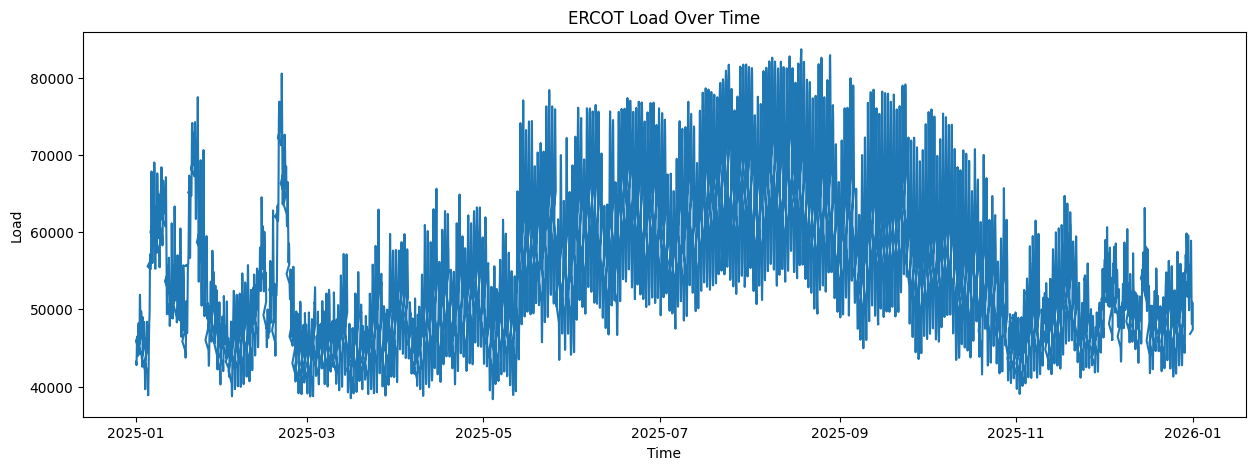

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['ERCOT'])

plt.title('ERCOT Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

plt.show()

    Raw 2025 ERCOT load over time
    Shows seasonal behavior clearly: summer load is much higher and more volatile.

In [ ]:
df.loc[df['ERCOT'].idxmax()]

,5512
Hour Ending,2025-08-18 18:00:00
COAST,22349.497921
EAST,2888.690723
FWEST,7046.24676
NORTH,1942.520791
NCENT,26581.624761
SOUTH,6508.846311
SCENT,14519.96276
WEST,1841.611669
ERCOT,83679.001697


    Max load moment
    Peak is Aug 18, 2025 at 6 PM around 83,679 MW — very summer/HVAC-driven.
    

In [ ]:
df['Hour'] = df['Hour Ending'].dt.hour

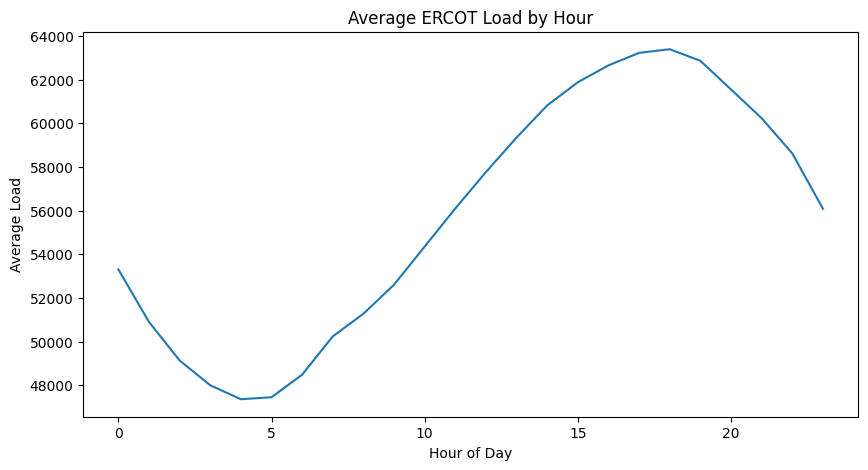

In [ ]:
hourly_avg = df.groupby('Hour')['ERCOT'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values)

plt.title('Average ERCOT Load by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Load')

plt.show()

    Average load by hour
    Nice smooth daily demand rhythm.


# 4. Seasonal Patterns


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create date/month/season columns
df['Date'] = df['Hour Ending'].dt.date
df['Month'] = df['Hour Ending'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

df[['Hour Ending', 'Hour', 'Month', 'Season', 'ERCOT']].head()

,Hour Ending,Hour,Month,Season,ERCOT
0,2025-01-01 01:00:00,1,1,Winter,43223.859905
1,2025-01-01 02:00:00,2,1,Winter,43122.532212
2,2025-01-01 03:00:00,3,1,Winter,42918.511847
3,2025-01-01 04:00:00,4,1,Winter,42780.783583
4,2025-01-01 05:00:00,5,1,Winter,43253.234707


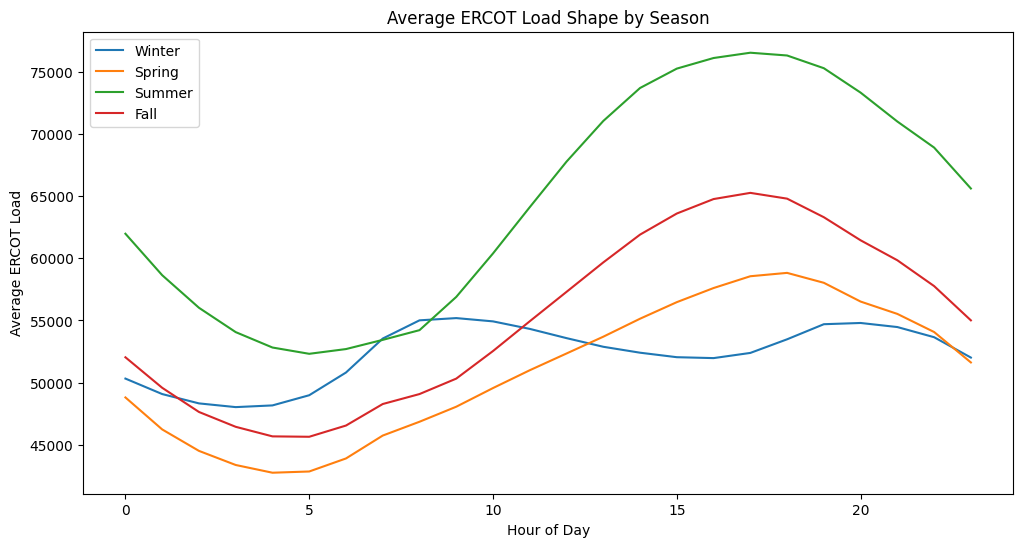

In [ ]:
seasonal_hourly = (
    df.groupby(['Season', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

plt.figure(figsize=(12,6))

for season in season_order:
    subset = seasonal_hourly[seasonal_hourly['Season'] == season]
    plt.plot(subset['Hour'], subset['ERCOT'], label=season)

plt.title('Average ERCOT Load Shape by Season')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.show()

    shows winter behaves differently from summer/fall.

In [ ]:
df = df.sort_values('Hour Ending')

df['Load_Change'] = df['ERCOT'].diff()
df['Abs_Load_Change'] = df['Load_Change'].abs()

df[['Hour Ending', 'ERCOT', 'Load_Change', 'Abs_Load_Change']].head()

,Hour Ending,ERCOT,Load_Change,Abs_Load_Change
23,2025-01-01 00:00:00,45875.362111,NaN,NaN
0,2025-01-01 01:00:00,43223.859905,-2651.502206,2651.502206
1,2025-01-01 02:00:00,43122.532212,-101.327693,101.327693
2,2025-01-01 03:00:00,42918.511847,-204.020365,204.020365
3,2025-01-01 04:00:00,42780.783583,-137.728264,137.728264


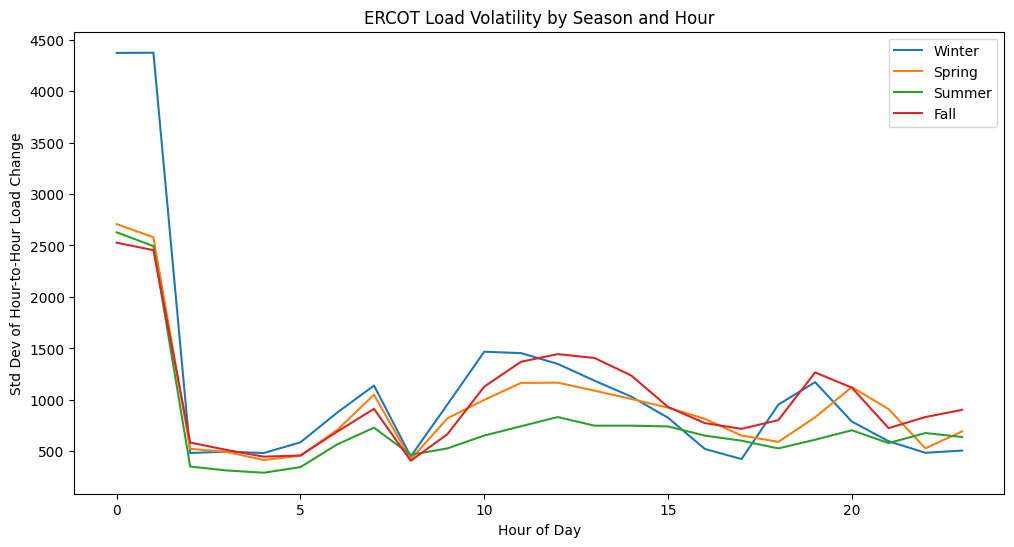

In [ ]:
seasonal_volatility = (
    df.groupby(['Season', 'Hour'])['Load_Change']
    .std()
    .reset_index()
)

plt.figure(figsize=(12,6))

for season in season_order:
    subset = seasonal_volatility[seasonal_volatility['Season'] == season]
    plt.plot(subset['Hour'], subset['Load_Change'], label=season)

plt.title('ERCOT Load Volatility by Season and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Std Dev of Hour-to-Hour Load Change')
plt.legend()
plt.show()


# 5. Stress vs Normal Days


In [ ]:
daily_peak = df.groupby('Date')['ERCOT'].max()

stress_threshold = daily_peak.quantile(0.90)
print("Stress threshold:", stress_threshold)


stress_days = daily_peak[daily_peak >= stress_threshold].index

df['Day_Type'] = np.where(df['Date'].isin(stress_days), 'Stress', 'Normal')

df[['Hour Ending', 'Date', 'ERCOT', 'Day_Type']].head()

Stress threshold: 78507.1686474


,Hour Ending,Date,ERCOT,Day_Type
23,2025-01-01 00:00:00,2025-01-01,45875.362111,Normal
0,2025-01-01 01:00:00,2025-01-01,43223.859905,Normal
1,2025-01-01 02:00:00,2025-01-01,43122.532212,Normal
2,2025-01-01 03:00:00,2025-01-01,42918.511847,Normal
3,2025-01-01 04:00:00,2025-01-01,42780.783583,Normal


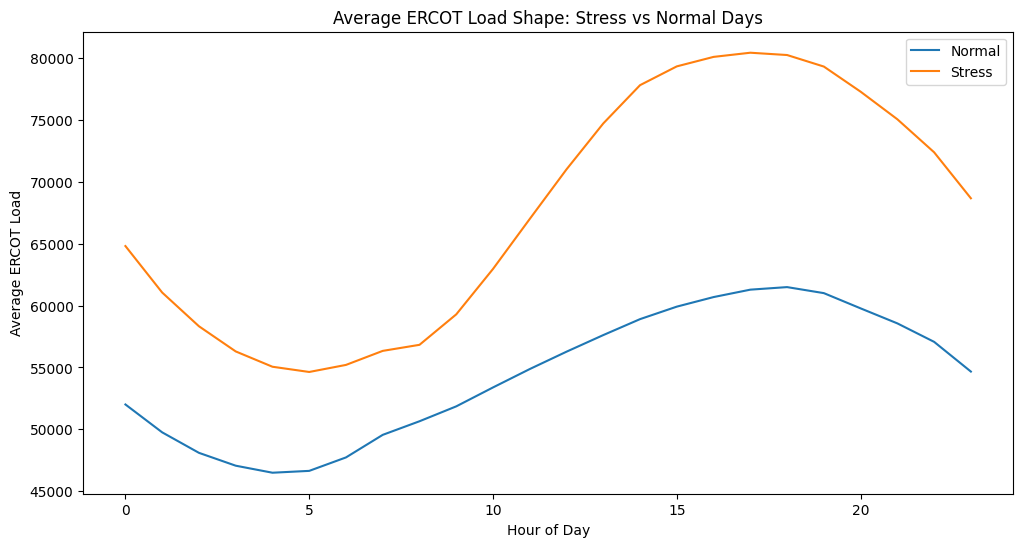

In [ ]:
stress_hourly = (
    df.groupby(['Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for day_type in ['Normal', 'Stress']:
    subset = stress_hourly[stress_hourly['Day_Type'] == day_type]
    plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

plt.title('Average ERCOT Load Shape: Stress vs Normal Days')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.show()

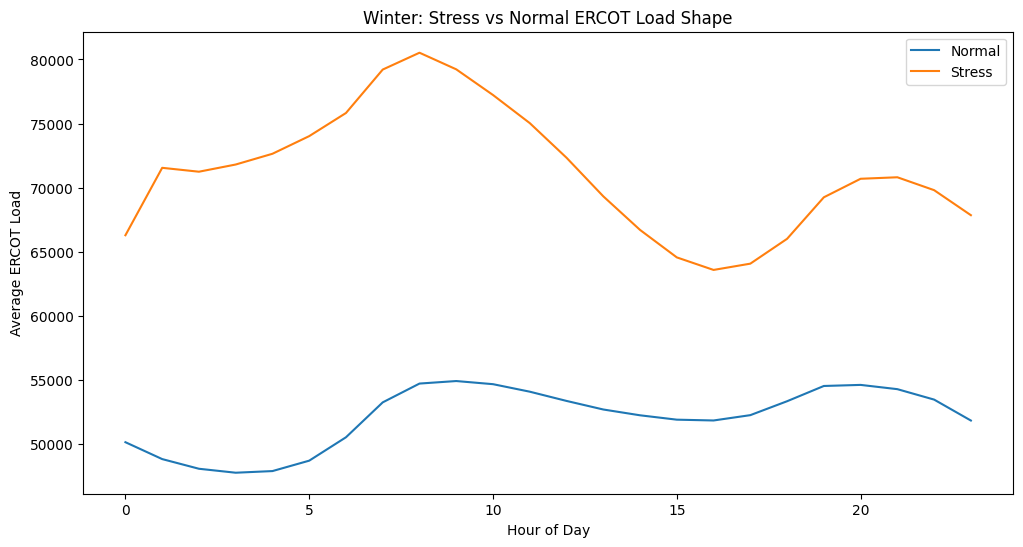

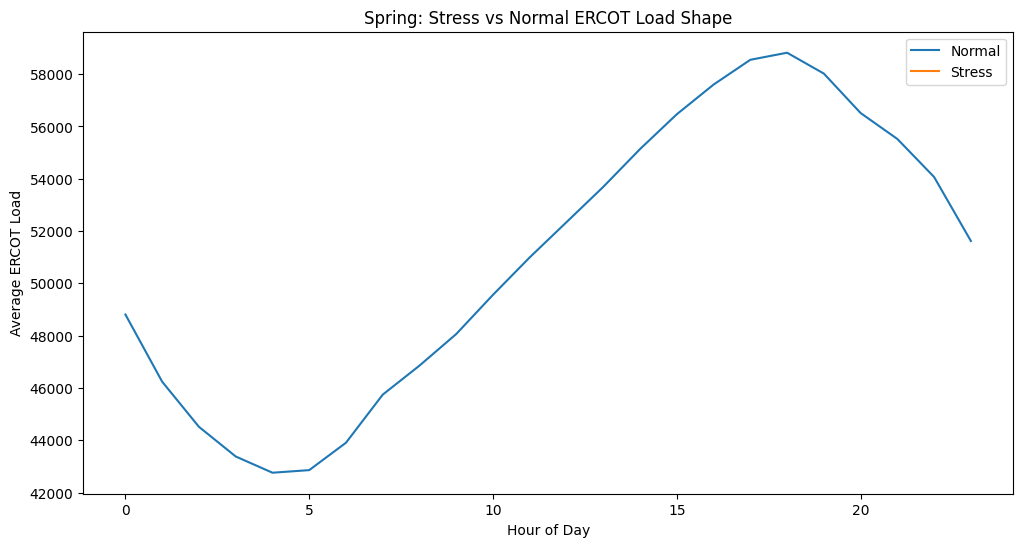

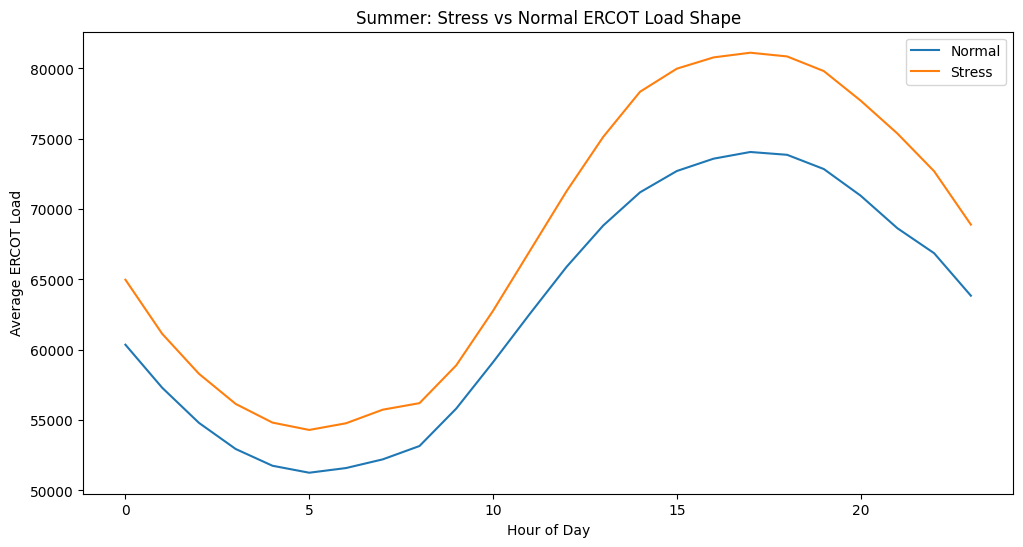

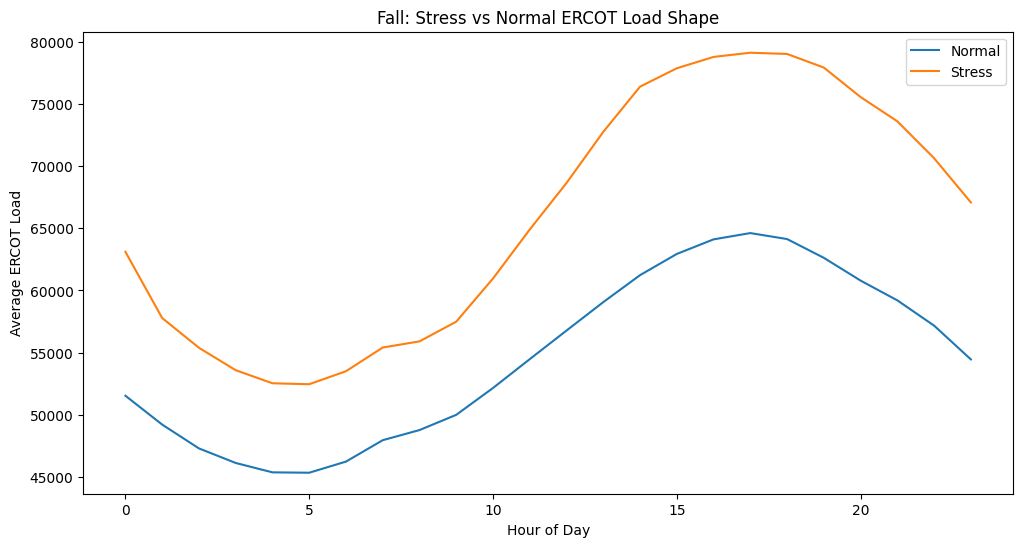

In [ ]:
season_stress_hourly = (
    df.groupby(['Season', 'Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

for season in season_order:
    subset_season = season_stress_hourly[season_stress_hourly['Season'] == season]

    plt.figure(figsize=(12,6))

    for day_type in ['Normal', 'Stress']:
        subset = subset_season[subset_season['Day_Type'] == day_type]
        plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

    plt.title(f'{season}: Stress vs Normal ERCOT Load Shape')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average ERCOT Load')
    plt.legend()
    plt.show()

In [ ]:
# Define stress days within each season instead of across the whole year

daily = (
    df.groupby(['Date', 'Season'])['ERCOT']
    .max()
    .reset_index(name='Daily_Peak')
)

daily['Season_Stress_Threshold'] = daily.groupby('Season')['Daily_Peak'].transform(
    lambda x: x.quantile(0.90)
)

daily['Season_Day_Type'] = np.where(
    daily['Daily_Peak'] >= daily['Season_Stress_Threshold'],
    'Stress',
    'Normal'
)

df = df.merge(
    daily[['Date', 'Season_Day_Type']],
    on='Date',
    how='left'
)

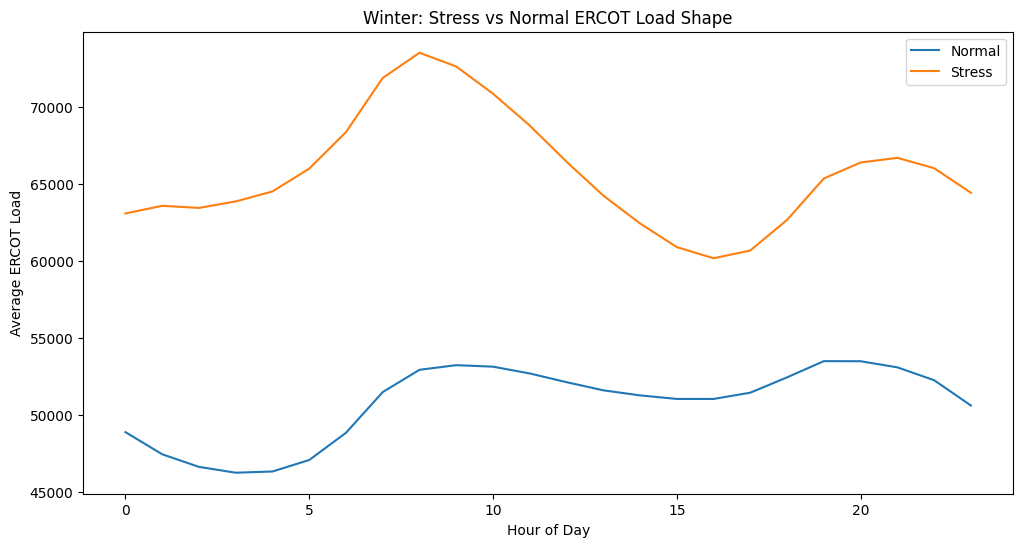

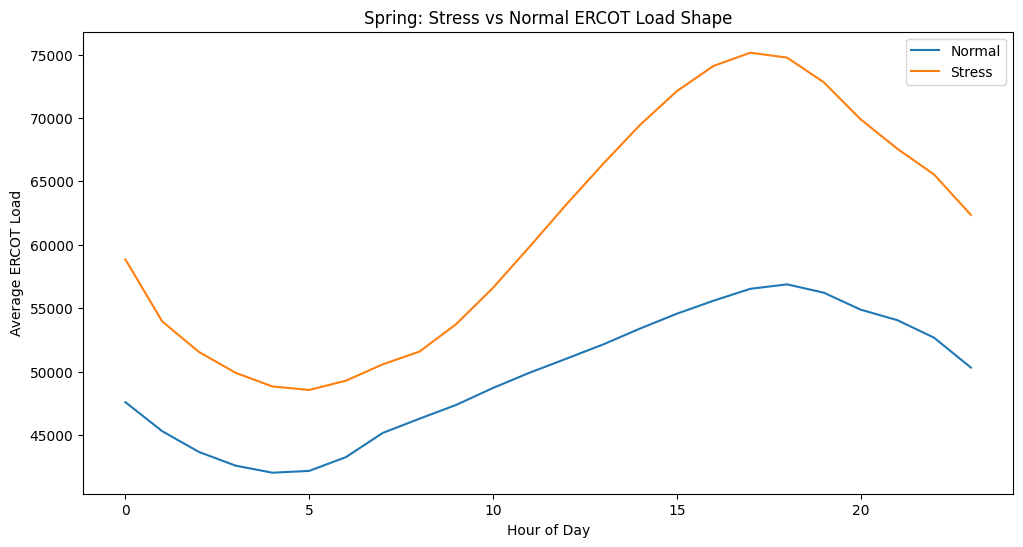

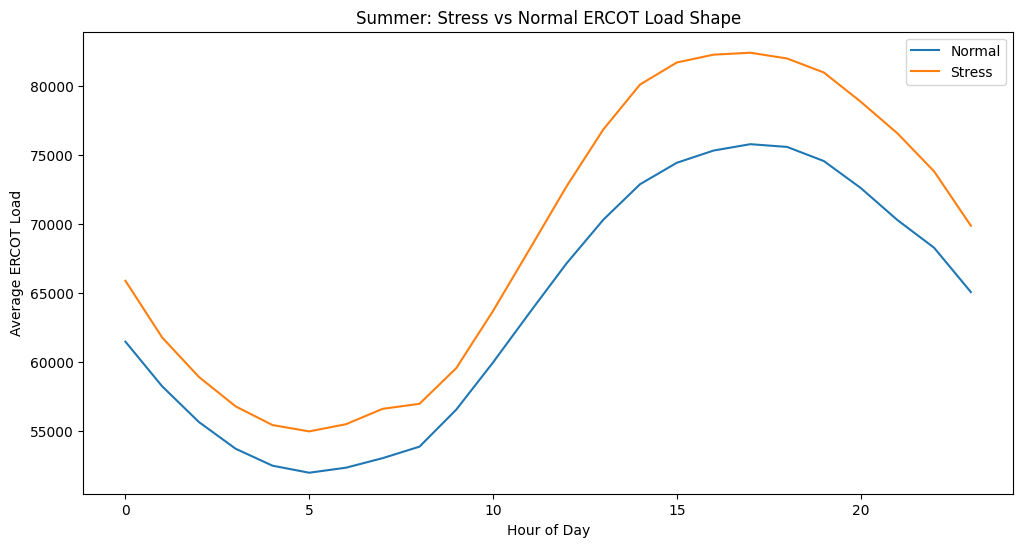

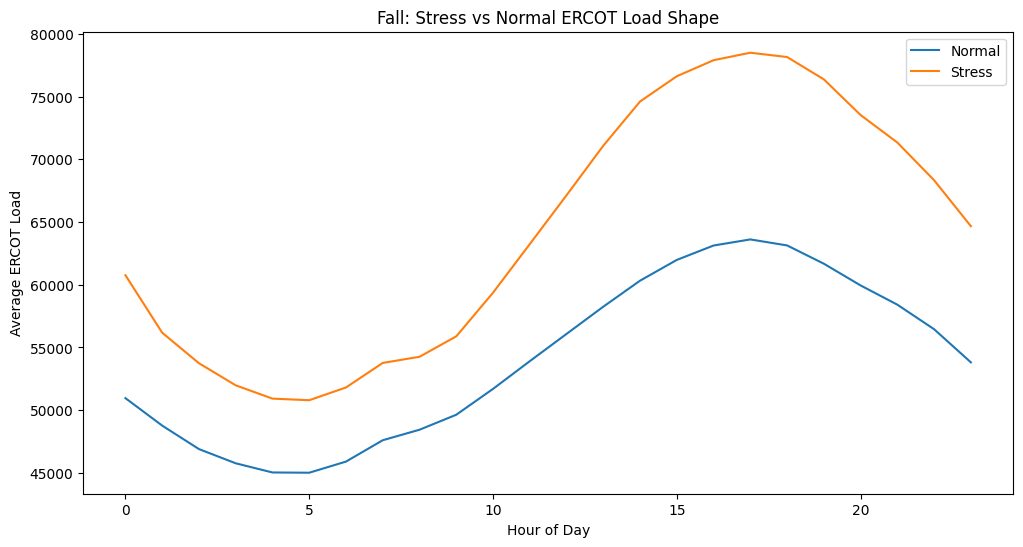

In [ ]:
season_stress_hourly = (
    df.groupby(['Season', 'Season_Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

for season in season_order:
    subset_season = season_stress_hourly[season_stress_hourly['Season'] == season]

    plt.figure(figsize=(12,6))

    for day_type in ['Normal', 'Stress']:
        subset = subset_season[subset_season['Season_Day_Type'] == day_type]
        plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

    plt.title(f'{season}: Stress vs Normal ERCOT Load Shape')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average ERCOT Load')
    plt.legend()
    plt.show()

Winter ERCOT stress is driven by persistent heating demand and morning ramp behavior rather than solar/AC afternoon peaks.Winter ERCOT stress is driven by persistent heating demand and morning ramp behavior rather than solar/AC afternoon peaks.


ERCOT can absorb spring load growth more smoothly because weather volatility is lower.

Summer stress is not anomalous behavior.
It is amplification of normal ERCOT summer dynamics

Fall is intereting because its alomst behaving like a mini summer.

In [ ]:

# 6. Add Weather Data
# 7. Weather vs Load Analysis
# 8. Initial Findings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading NOAA Weather Data
weather_path = '/content/drive/MyDrive/energy-reliability-systems/data/LCD_USW00012918_2025.csv'

weather = pd.read_csv(weather_path)


/tmp/ipykernel_11139/2095840352.py:4: DtypeWarning: Columns (19,23,27,33,34,35,36,42,60,61,90,91,92,93,94,95,96,97,98,99,100,101,113) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv(weather_path)


In [ ]:
# Preview data
print("Weather Data Preview:")
display(weather.head())

print("\nWeather Columns:")
print(weather.columns)



Weather Data Preview:


,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,SOURCE,HourlyAltimeterSetting,HourlyDewPointTemperature,...,BackupDirection,BackupDistance,BackupDistanceUnit,BackupElements,BackupElevation,BackupEquipment,BackupLatitude,BackupLongitude,BackupName,WindEquipmentChangeDate
0,USW00012918,2025-01-01T00:00:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",SOD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
1,USW00012918,2025-01-01T00:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1021.0,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
2,USW00012918,2025-01-01T01:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1021.7,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
3,USW00012918,2025-01-01T02:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1022.0,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
4,USW00012918,2025-01-01T03:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1022.4,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007



Weather Columns:
Index(['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME',
       'REPORT_TYPE', 'SOURCE', 'HourlyAltimeterSetting',
       'HourlyDewPointTemperature',
       ...
       'BackupDirection', 'BackupDistance', 'BackupDistanceUnit',
       'BackupElements', 'BackupElevation', 'BackupEquipment',
       'BackupLatitude', 'BackupLongitude', 'BackupName',
       'WindEquipmentChangeDate'],
      dtype='object', length=125)


In [ ]:
# Clean Weather Data

# Convert datetime column
weather['DATE'] = pd.to_datetime(weather['DATE'])

# Convert temperature column to numeric
weather['HourlyDryBulbTemperature'] = pd.to_numeric(
    weather['HourlyDryBulbTemperature'],
    errors='coerce'
)

# Keeping only columns I need
weather_clean = weather[
    ['DATE', 'HourlyDryBulbTemperature']
].dropna()

print("\nCleaned Weather Data:")
display(weather_clean.head())



Cleaned Weather Data:


,DATE,HourlyDryBulbTemperature
1,2025-01-01 00:53:00,13.3
2,2025-01-01 01:53:00,12.2
3,2025-01-01 02:53:00,11.7
4,2025-01-01 03:53:00,11.1
5,2025-01-01 04:53:00,10.6


In [ ]:
# Prepare ERCOT Data

# Make sure ERCOT timestamps are datetime
df['Hour Ending'] = pd.to_datetime(df['Hour Ending'])

# Sort both datasets
df_sorted = df.sort_values('Hour Ending')
weather_sorted = weather_clean.sort_values('DATE')


In [ ]:
# Merge Weather + ERCOT

merged = pd.merge_asof(
    df_sorted,
    weather_sorted,
    left_on='Hour Ending',
    right_on='DATE',
    direction='nearest'
)

print("\nMerged Dataset:")
display(merged.head())



Merged Dataset:


,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,Hour,Date,Month,Season,Load_Change,Abs_Load_Change,Day_Type,Season_Day_Type,DATE,HourlyDryBulbTemperature
0,2025-01-01 00:00:00,11034.358814,1652.581239,7136.447964,1465.449832,13431.830740,3258.146198,6625.440094,1271.107229,45875.362111,0,2025-01-01,1,Winter,NaN,NaN,Normal,Normal,2025-01-01 00:53:00,13.3
1,2025-01-01 01:00:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905,1,2025-01-01,1,Winter,-2651.502206,2651.502206,Normal,Normal,2025-01-01 00:53:00,13.3
2,2025-01-01 02:00:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212,2,2025-01-01,1,Winter,-101.327693,101.327693,Normal,Normal,2025-01-01 01:53:00,12.2
3,2025-01-01 03:00:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847,3,2025-01-01,1,Winter,-204.020365,204.020365,Normal,Normal,2025-01-01 02:53:00,11.7
4,2025-01-01 04:00:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583,4,2025-01-01,1,Winter,-137.728264,137.728264,Normal,Normal,2025-01-01 03:53:00,11.1


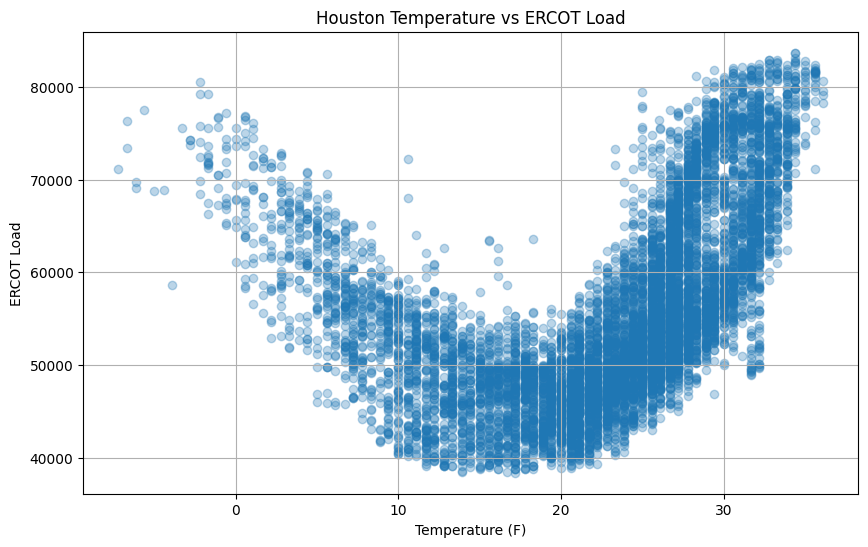

In [ ]:
#  Temperature vs ERCOT Load

plt.figure(figsize=(10,6))

plt.scatter(
    merged['HourlyDryBulbTemperature'],
    merged['ERCOT'],
    alpha=0.3
)

plt.title('Houston Temperature vs ERCOT Load')
plt.xlabel('Temperature (F)')
plt.ylabel('ERCOT Load')

plt.grid(True)
plt.show()


At mild temperatures (~15–20°C / ~60–70°F equivalent), ERCOT load is lowest.

As temperatures move:

* colder → heating demand rises
* hotter → AC demand rises

That’s why the shape bends upward on BOTH sides.

In [ ]:
# Correlation

correlation = merged[
    ['HourlyDryBulbTemperature', 'ERCOT']
].corr()

print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
                          HourlyDryBulbTemperature     ERCOT
HourlyDryBulbTemperature                  1.000000  0.420947
ERCOT                                     0.420947  1.000000


correlation being only ~0.42 is actually interesting because:

* the relationship is nonlinear
* simple Pearson correlation underestimates weather effects
* this is exactly why utilities use nonlinear load forecasting models

In [ ]:
merged['Temp_F'] = (merged['HourlyDryBulbTemperature'] * 9/5) + 32

changing to fahrenheit

In [ ]:
merged['Hour'] = merged['Hour Ending'].dt.hour

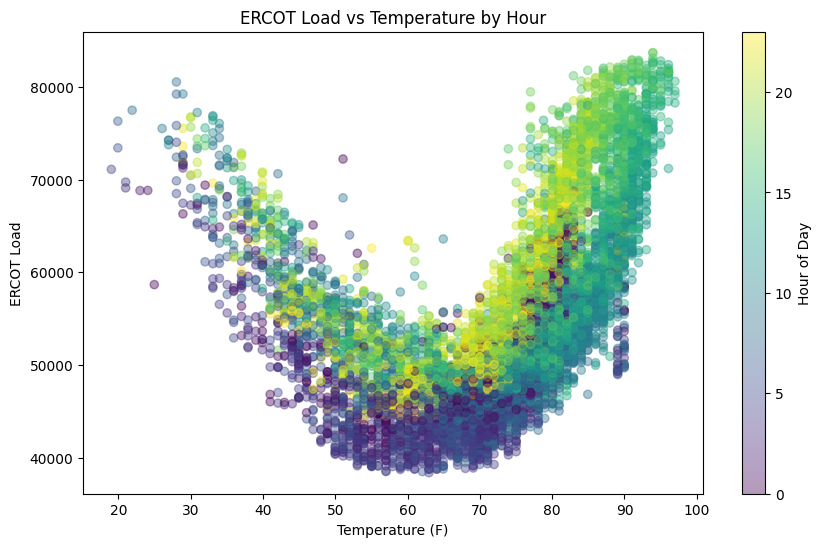

In [ ]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    merged['Temp_F'],
    merged['ERCOT'],
    c=merged['Hour'],
    alpha=0.4
)

plt.colorbar(label='Hour of Day')

plt.xlabel('Temperature (F)')
plt.ylabel('ERCOT Load')
plt.title('ERCOT Load vs Temperature by Hour')

plt.show()


## Observation: Temperature, Time of Day, and ERCOT Load

This scatterplot shows a nonlinear relationship between Houston temperature and ERCOT load. Load is lowest during mild temperatures and rises when temperatures become very cold or very hot.

The color gradient adds an important timing layer: hotter temperatures are concentrated later in the day, while colder temperatures are more common overnight and early morning. This suggests that ERCOT load is shaped not only by temperature, but also by the timing of human activity and weather cycles.

The hot-weather side of the curve appears steeper, indicating that ERCOT demand may be more sensitive to extreme heat than to moderate cold conditions.

In [ ]:
merged['Load_Deviation'] = (
    merged['ERCOT'] - merged['ERCOT'].mean()
) / merged['ERCOT'].std()


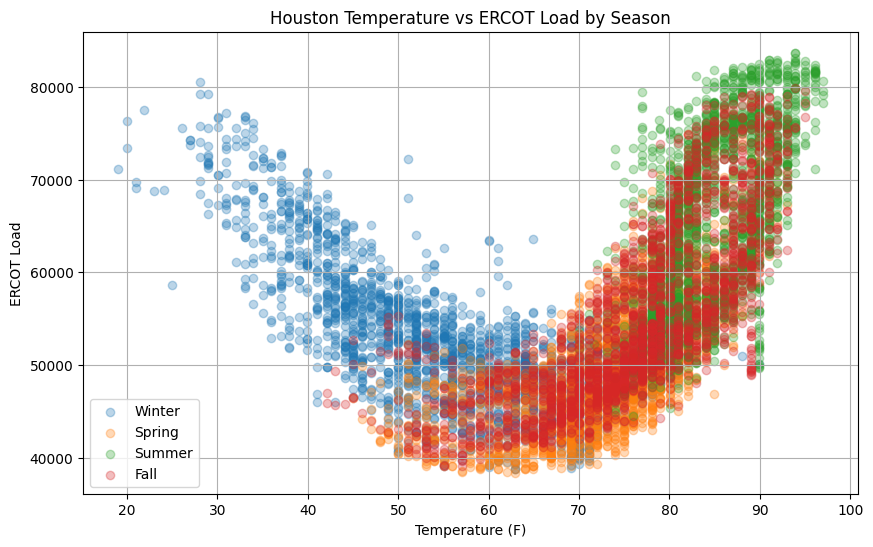

In [ ]:
# Temperature vs Load by Season

plt.figure(figsize=(10,6))

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    subset = merged[merged['Season'] == season]

    plt.scatter(
        subset['Temp_F'],
        subset['ERCOT'],
        alpha=0.3,
        label=season
    )

plt.title('Houston Temperature vs ERCOT Load by Season')
plt.xlabel('Temperature (F)')
plt.ylabel('ERCOT Load')
plt.legend()
plt.grid(True)
plt.show()

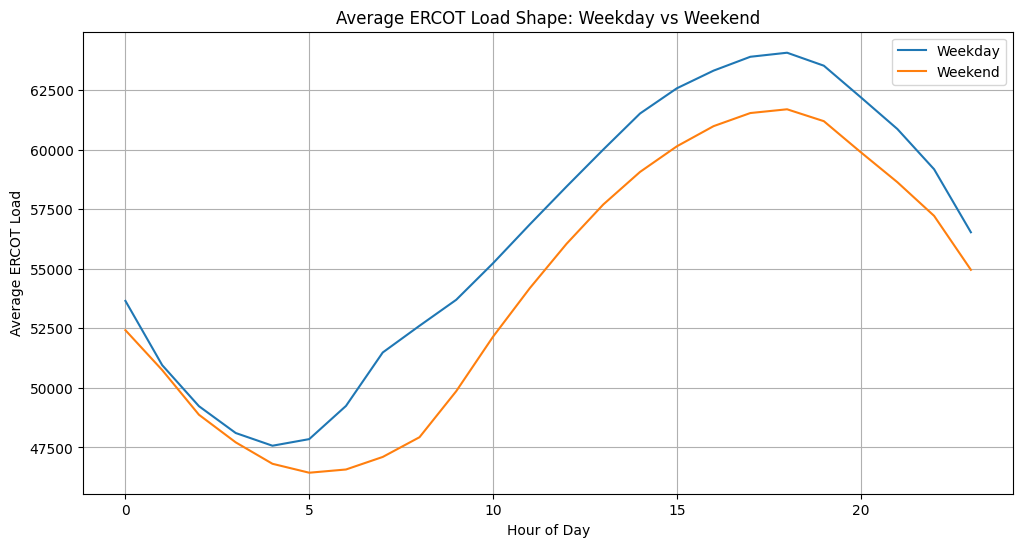

In [ ]:
# Weekday vs Weekend Load Behavior

merged['DayOfWeek'] = merged['Hour Ending'].dt.dayofweek

merged['Day_Category'] = np.where(
    merged['DayOfWeek'].isin([5, 6]),
    'Weekend',
    'Weekday'
)

weekday_hourly = (
    merged.groupby(['Day_Category', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for day_type in ['Weekday', 'Weekend']:
    subset = weekday_hourly[weekday_hourly['Day_Category'] == day_type]

    plt.plot(
        subset['Hour'],
        subset['ERCOT'],
        label=day_type
    )

plt.title('Average ERCOT Load Shape: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.grid(True)
plt.show()

## Observation: Weekday vs Weekend Load Behavior

ERCOT load follows a similar daily shape on both weekdays and weekends, but weekday demand is consistently higher throughout most of the day.

The largest divergence appears during business hours and the late afternoon peak period, likely reflecting commercial and industrial activity. Weekend demand rises more gradually and reaches a lower peak overall.

This suggests that human behavior and economic activity patterns materially influence grid demand beyond weather effects alone.

Mean Absolute Error: 1925.0820067036357
R-squared: 0.9322510718214299


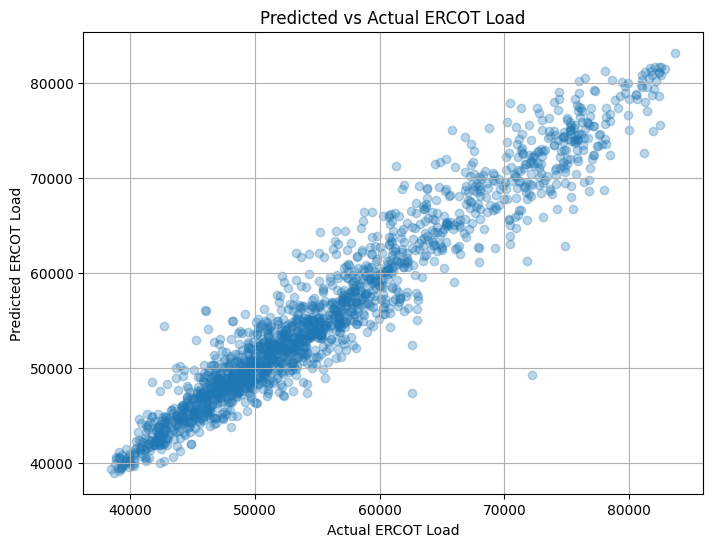

In [ ]:
# Basic Peak Load Predictor

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_df = merged.copy()

model_df['IsWeekend'] = np.where(model_df['DayOfWeek'].isin([5, 6]), 1, 0)
model_df['Month'] = model_df['Hour Ending'].dt.month

model_df = model_df.dropna(subset=['Temp_F', 'Hour', 'DayOfWeek', 'Month', 'ERCOT'])

features = ['Temp_F', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend']
target = 'ERCOT'

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R-squared:", r2)

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.3)

plt.title('Predicted vs Actual ERCOT Load')
plt.xlabel('Actual ERCOT Load')
plt.ylabel('Predicted ERCOT Load')
plt.grid(True)
plt.show()

## Observation: ERCOT Load Prediction Model

The Random Forest model performs well at predicting ERCOT load using temperature, hour of day, calendar features, and weekend indicators.

Predicted values closely follow actual load observations, indicating that weather and temporal variables explain a significant portion of ERCOT demand variability.

Prediction spread increases during higher load conditions, suggesting that extreme demand periods may involve additional drivers such as market behavior, outages, or rapid weather shifts.

In [ ]:
#  Extreme Day Detection
daily_summary = (
    merged.groupby('Date')
    .agg(
        Daily_Peak_Load=('ERCOT', 'max'),
        Daily_Avg_Load=('ERCOT', 'mean'),
        Daily_Max_Temp=('Temp_F', 'max'),
        Daily_Min_Temp=('Temp_F', 'min'),
        Daily_Avg_Temp=('Temp_F', 'mean'),
        Max_Hourly_Ramp=('Abs_Load_Change', 'max')
    )
    .reset_index()
)

peak_threshold = daily_summary['Daily_Peak_Load'].quantile(0.95)
ramp_threshold = daily_summary['Max_Hourly_Ramp'].quantile(0.95)
temp_threshold = daily_summary['Daily_Max_Temp'].quantile(0.95)

daily_summary['Extreme_Day'] = np.where(
    (daily_summary['Daily_Peak_Load'] >= peak_threshold) |
    (daily_summary['Max_Hourly_Ramp'] >= ramp_threshold) |
    (daily_summary['Daily_Max_Temp'] >= temp_threshold),
    'Extreme',
    'Normal'
)

daily_summary.sort_values('Daily_Peak_Load', ascending=False).head(10)

,Date,Daily_Peak_Load,Daily_Avg_Load,Daily_Max_Temp,Daily_Min_Temp,Daily_Avg_Temp,Max_Hourly_Ramp,Extreme_Day
229,2025-08-18,83679.001697,70185.283074,96.08,80.06,87.2375,4970.630721,Extreme
239,2025-08-28,82907.273669,68467.484765,93.92,78.08,85.1600,4134.059997,Extreme
225,2025-08-14,82757.910024,69775.173452,95.00,80.06,87.0425,8055.818848,Extreme
219,2025-08-08,82589.021176,69993.000666,96.08,78.98,86.0375,5309.413063,Extreme
236,2025-08-25,82580.922424,67196.727202,93.92,78.08,85.3700,4559.818674,Extreme
218,2025-08-07,82111.271583,69131.606702,95.00,78.98,85.3775,4760.744204,Extreme
220,2025-08-09,82079.043659,68746.926833,93.92,80.06,85.5125,5707.193837,Extreme
222,2025-08-11,82061.278338,68527.376784,93.02,78.08,85.0925,4644.133657,Extreme
230,2025-08-19,82053.227132,68514.793413,91.94,80.96,84.9875,6703.139511,Extreme
228,2025-08-17,81823.878801,68078.482707,96.98,78.08,86.8700,4734.361965,Extreme


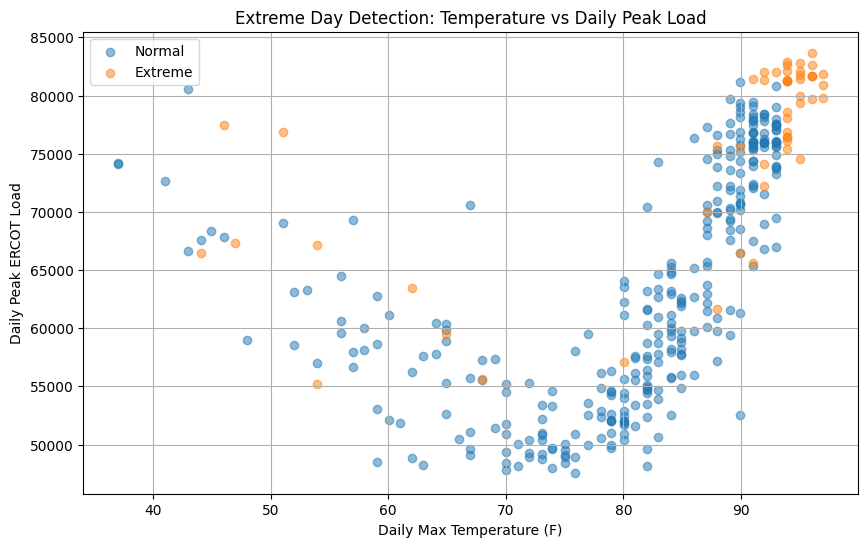

In [ ]:
# Visualize extreme days

plt.figure(figsize=(10,6))

for label in ['Normal', 'Extreme']:
    subset = daily_summary[daily_summary['Extreme_Day'] == label]

    plt.scatter(
        subset['Daily_Max_Temp'],
        subset['Daily_Peak_Load'],
        alpha=0.5,
        label=label
    )

plt.title('Extreme Day Detection: Temperature vs Daily Peak Load')
plt.xlabel('Daily Max Temperature (F)')
plt.ylabel('Daily Peak ERCOT Load')
plt.legend()
plt.grid(True)
plt.show()

## Observation: Extreme Day Detection

Extreme ERCOT load days cluster primarily around very high temperatures, reinforcing the strong relationship between heat and grid stress in Texas.

A smaller number of extreme days also occur during colder conditions, likely associated with winter heating demand and weather-related operational stress.

The visualization suggests that high-temperature events are more consistently associated with peak system demand than moderate temperature ranges.

## 8. Ramp Analysis

In [ ]:


# Make sure data is sorted
merged = merged.sort_values('Hour Ending')

# Hour-to-hour load change
merged['Load_Change'] = merged['ERCOT'].diff()
merged['Abs_Load_Change'] = merged['Load_Change'].abs()

# Preview
merged[['Hour Ending', 'ERCOT', 'Load_Change', 'Abs_Load_Change', 'Temp_F']].head()

,Hour Ending,ERCOT,Load_Change,Abs_Load_Change,Temp_F
0,2025-01-01 00:00:00,45875.362111,NaN,NaN,55.94
1,2025-01-01 01:00:00,43223.859905,-2651.502206,2651.502206,55.94
2,2025-01-01 02:00:00,43122.532212,-101.327693,101.327693,53.96
3,2025-01-01 03:00:00,42918.511847,-204.020365,204.020365,53.06
4,2025-01-01 04:00:00,42780.783583,-137.728264,137.728264,51.98


In [ ]:
# Biggest upward ramps
top_up_ramps = merged.sort_values('Load_Change', ascending=False)[
    ['Hour Ending', 'ERCOT', 'Load_Change', 'Temp_F', 'Hour', 'Season', 'Day_Category']
].head(10)

top_up_ramps

,Hour Ending,ERCOT,Load_Change,Temp_F,Hour,Season,Day_Category
1152,2025-02-18 00:00:00,62036.637459,12568.814624,53.06,0,Winter,Weekday
96,2025-01-05 00:00:00,55569.669327,10755.262936,66.92,0,Winter,Weekend
505,2025-01-22 01:00:00,68824.620574,10163.563023,24.08,1,Winter,Weekday
1176,2025-02-19 00:00:00,72213.191182,9627.279945,51.08,0,Winter,Weekday
432,2025-01-19 00:00:00,65091.188048,9494.750345,46.94,0,Winter,Weekend
408,2025-01-18 00:00:00,55646.940465,8275.574590,64.94,0,Winter,Weekend
577,2025-01-25 01:00:00,53783.897332,7761.698509,37.94,1,Winter,Weekend
1249,2025-02-22 01:00:00,62326.035340,7747.232409,39.02,1,Winter,Weekend
3480,2025-05-26 01:00:00,58956.697127,7679.985814,82.04,1,Spring,Weekday
241,2025-01-11 01:00:00,61003.635069,7366.332416,39.92,1,Winter,Weekend


In [ ]:
# Biggest downward ramps
top_down_ramps = merged.sort_values('Load_Change', ascending=True)[
    ['Hour Ending', 'ERCOT', 'Load_Change', 'Temp_F', 'Hour', 'Season', 'Day_Category']
].head(10)

top_down_ramps

,Hour Ending,ERCOT,Load_Change,Temp_F,Hour,Season,Day_Category
1153,2025-02-18 01:00:00,45736.744407,-16299.893052,55.04,1,Winter,Weekday
3479,2025-05-26 00:00:00,51276.711313,-13995.173022,82.04,0,Spring,Weekday
97,2025-01-05 01:00:00,41702.971072,-13866.698255,68.00,1,Winter,Weekend
504,2025-01-22 00:00:00,58661.057551,-11835.731505,24.98,0,Winter,Weekday
6383,2025-09-24 00:00:00,56390.054366,-11375.380603,80.96,0,Fall,Weekday
3959,2025-06-15 00:00:00,53250.960528,-11077.470196,80.06,0,Summer,Weekend
409,2025-01-18 01:00:00,44630.503315,-11016.437150,66.02,1,Winter,Weekend
3984,2025-06-16 01:00:00,50616.120086,-10885.799812,73.94,1,Summer,Weekday
1177,2025-02-19 01:00:00,61457.186598,-10756.004584,48.02,1,Winter,Weekday
1248,2025-02-22 00:00:00,54578.802931,-10701.526256,39.92,0,Winter,Weekend


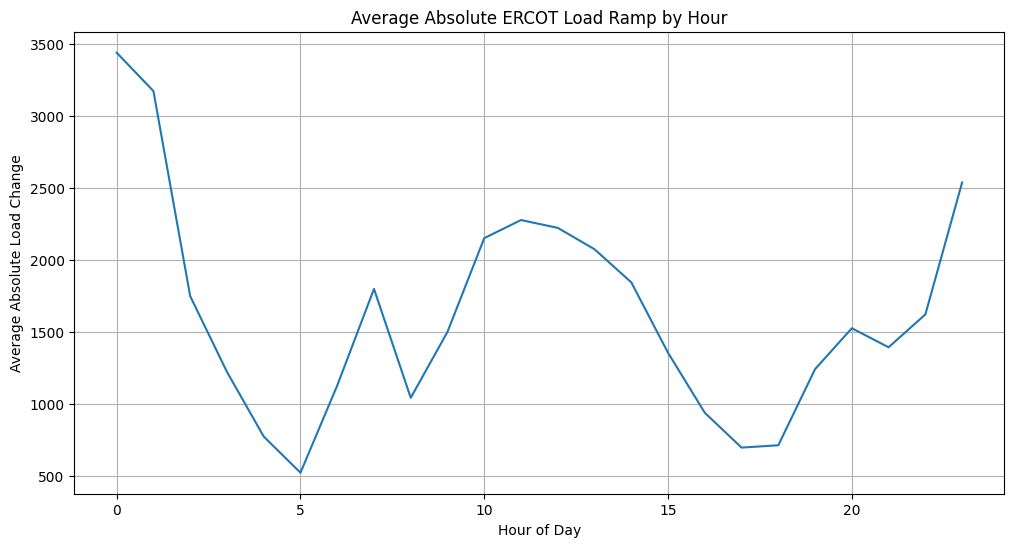

In [ ]:
# Average ramp by hour
hourly_ramp = (
    merged.groupby('Hour')['Abs_Load_Change']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(hourly_ramp['Hour'], hourly_ramp['Abs_Load_Change'])

plt.title('Average Absolute ERCOT Load Ramp by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Absolute Load Change')
plt.grid(True)
plt.show()

## Observation: Average ERCOT Ramp Behavior

ERCOT experiences the largest average load changes during late-night and morning transition periods.

Ramp magnitude decreases during midday hours when load behavior becomes more stable, then increases again during afternoon and evening demand growth periods.

This suggests that transition periods between low-demand and high-demand conditions create the most dynamic operational environments for the grid.

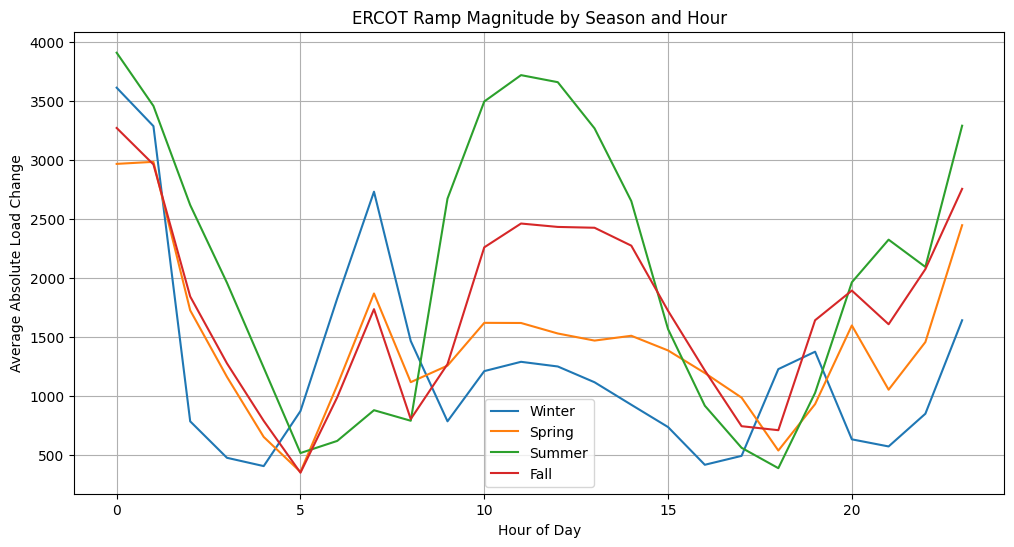

In [ ]:
# Ramp behavior by season
seasonal_ramp = (
    merged.groupby(['Season', 'Hour'])['Abs_Load_Change']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    subset = seasonal_ramp[seasonal_ramp['Season'] == season]
    plt.plot(subset['Hour'], subset['Abs_Load_Change'], label=season)

plt.title('ERCOT Ramp Magnitude by Season and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Absolute Load Change')
plt.legend()
plt.grid(True)
plt.show()

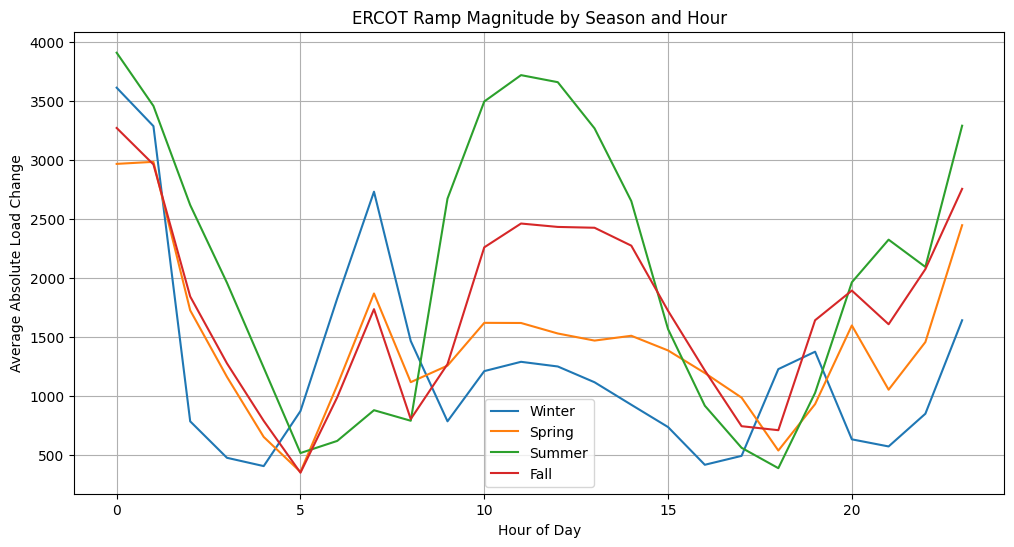

In [ ]:
# Ramp behavior by season
seasonal_ramp = (
    merged.groupby(['Season', 'Hour'])['Abs_Load_Change']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    subset = seasonal_ramp[seasonal_ramp['Season'] == season]
    plt.plot(subset['Hour'], subset['Abs_Load_Change'], label=season)

plt.title('ERCOT Ramp Magnitude by Season and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Absolute Load Change')
plt.legend()
plt.grid(True)
plt.show()

## Observation: Seasonal Ramp Differences

Summer exhibits the strongest and most sustained ramp behavior, particularly during late morning and afternoon hours when cooling demand increases rapidly.

Winter ramps appear sharper and more concentrated during specific hours, likely reflecting sudden heating demand changes during cold events.

Spring and fall show lower overall ramp magnitudes, consistent with milder weather conditions and reduced temperature-driven load stress.

# 9. Daily Load Shape Clustering



# Section 9 — Daily Load Shape Clustering

In this section, we move from analyzing individual hours of ERCOT load to analyzing entire days as operational patterns.

Each day is represented as a 24-hour load profile, where every hour acts as a feature describing the behavior of the grid throughout the day.

We then use unsupervised machine learning (KMeans clustering) to group similar operating days together based on the shape of their demand curves.

This helps identify:
- high-stress summer demand regimes
- mild low-demand operating conditions
- moderate seasonal behavior
- rare or anomalous system states

This type of analysis is commonly used in:
- grid reliability studies
- operational regime detection
- demand forecasting
- anomaly detection
- power systems research

In [ ]:
# Daily Load Shape Clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## Step 1 — Build Daily Load Profiles

We reshape the ERCOT hourly load data into daily operating profiles.

Each row now represents:
- one calendar day

Each column represents:
- one hour of the day (0–23)

This converts the dataset from:
- hourly observations

into:
- full daily system behavior fingerprints.

These daily profiles will later be clustered to identify recurring operational regimes.

In [ ]:
# Create Daily Hourly Load Profiles

daily_profiles = (
    merged.pivot_table(
        index='Date',
        columns='Hour',
        values='ERCOT'
    )
)

# Remove incomplete days
daily_profiles = daily_profiles.dropna()

print(daily_profiles.head())

Hour                  0             1             2             3   \
Date                                                                 
2025-01-01  45875.362111  43223.859905  43122.532212  42918.511847   
2025-01-02  45216.924798  44854.310359  44346.305653  44176.276220   
2025-01-03  43687.721032  43848.113347  43072.402949  42632.781535   
2025-01-04  43222.460090  42168.718002  41038.070722  40145.527651   
2025-01-05  55569.669327  41702.971072  40596.134196  39775.948081   

Hour                  4             5             6             7   \
Date                                                                 
2025-01-01  42780.783583  43253.234707  43984.988292  45192.086546   
2025-01-02  44364.443897  45422.975068  47293.685145  49745.866965   
2025-01-03  42568.300775  43167.101545  44641.090990  46811.567652   
2025-01-04  39662.289742  39653.021549  40247.742086  41307.165027   
2025-01-05  39154.079682  38872.517373  39256.130906  40183.544812   

Hour              

## Step 2 — Normalize Daily Profiles

Before clustering, we standardize the daily load profiles using StandardScaler.

Why scaling matters:
- clustering algorithms use distance calculations
- large numerical values can dominate results
- scaling allows the algorithm to focus on SHAPE rather than absolute magnitude

Without scaling:
- high-load days would overpower lower-load days

With scaling:
- days are grouped based on operational behavior patterns.

In [ ]:
# Scale Data
scaler = StandardScaler()

scaled_profiles = scaler.fit_transform(daily_profiles)

## Step 3 — Apply KMeans Clustering

We use KMeans clustering to identify groups of similar ERCOT operating days.

KMeans works by:
1. placing cluster centers
2. assigning each day to the nearest center
3. recalculating the centers
4. repeating until the clusters stabilize

The algorithm groups days that have similar 24-hour demand behavior.

In this notebook:
- n_clusters = 4

This means we are asking the algorithm to identify:
- four major operating regimes within ERCOT demand behavior.

In [ ]:
# KMeans Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_profiles)

daily_profiles['Cluster'] = clusters

## Step 4 — Map Cluster Labels Back to the Main Dataset

After clustering the daily profiles, we attach each day's cluster label back to the original hourly dataset.

This allows future analysis to compare:
- temperature
- ramps
- seasons
- extreme events
- operational behavior

across different cluster regimes.

In [ ]:
# Add Cluster Labels Back

cluster_map = daily_profiles['Cluster']

merged['Cluster'] = merged['Date'].map(cluster_map)

merged[['Date', 'Cluster']].head()

,Date,Cluster
0,2025-01-01,1.0
1,2025-01-01,1.0
2,2025-01-01,1.0
3,2025-01-01,1.0
4,2025-01-01,1.0


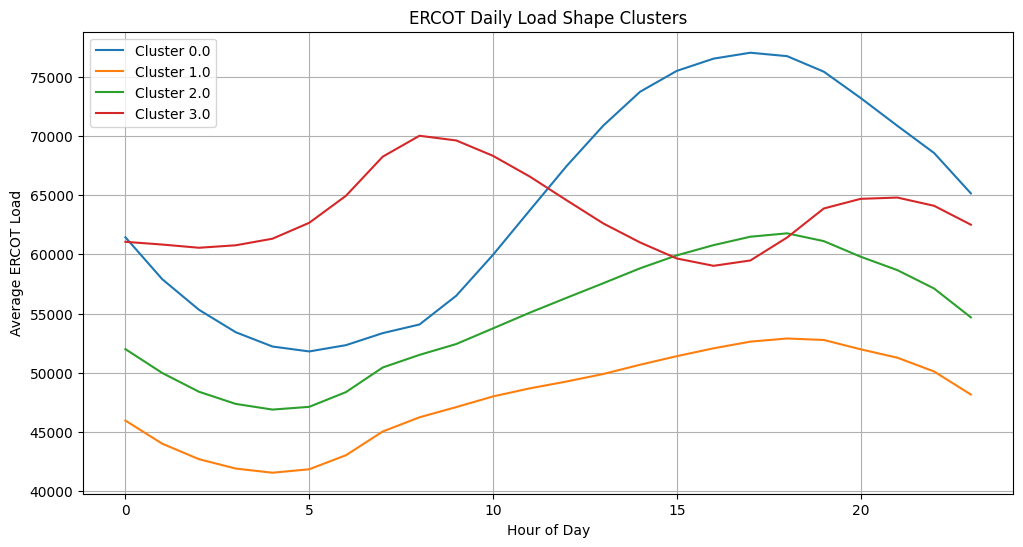

In [ ]:


# Visualize Cluster Average Load Shapes

cluster_hourly = (
    merged.groupby(['Cluster', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for cluster in sorted(cluster_hourly['Cluster'].unique()):

    subset = cluster_hourly[
        cluster_hourly['Cluster'] == cluster
    ]

    plt.plot(
        subset['Hour'],
        subset['ERCOT'],
        label=f'Cluster {cluster}'
    )

plt.title('ERCOT Daily Load Shape Clusters')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.grid(True)

plt.show()

### ERCOT Daily Load Shape Clusters — Interpretation

Observations from the clustering results:

- Some clusters show strong afternoon/evening peaks, likely representing high summer cooling demand days.
- Other clusters remain relatively flat and lower overall, suggesting mild weather or weekend conditions.
- One cluster appears rare and operationally distinct, potentially capturing abnormal system conditions or extreme weather events.

Key insight:
The grid does not operate in a single consistent way.

Instead, ERCOT transitions between multiple recurring operating regimes depending on:
- weather
- seasonality
- human activity patterns
- system stress conditions

This is an example of unsupervised system-state discovery.

In [ ]:
# Cluster Counts
cluster_counts = (
    merged[['Date', 'Cluster']]
    .drop_duplicates()['Cluster']
    .value_counts()
)

print(cluster_counts)

Cluster
1.0    133
0.0    120
2.0     94
3.0     17
Name: count, dtype: int64


### Cluster Distribution Interpretation

The results above show the number of days assigned to each cluster.

Interpretation:
- larger clusters represent common ERCOT operating behavior
- smaller clusters represent rare or specialized system states

In this analysis:
- Cluster 3 is much smaller than the others, suggesting it may capture unusual or extreme operating conditions.

Future research ideas:
- compare clusters against weather events
- identify if rare clusters align with grid stress periods
- analyze market prices during each regime
- examine regional load behavior differences across clusters

## 10. ERCOT Regional Network Relationships
 a.k.a. how connected are ERCOT regions?


add explain later


In [ ]:
# Regional Columns
regions = [
    'COAST',
    'EAST',
    'FWEST',
    'NORTH',
    'NCENT',
    'SOUTH',
    'SCENT',
    'WEST'
]

regional_data = merged[regions]

print("Regional Dataset:")
display(regional_data.head())

Regional Dataset:


,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST
0,11034.358814,1652.581239,7136.447964,1465.449832,13431.830740,3258.146198,6625.440094,1271.107229
1,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317
2,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659
3,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121
4,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069


In [ ]:
# Regional Correlation Matrix
regional_corr = regional_data.corr()

print("Regional Correlation Matrix:")
display(regional_corr)
# the closer the values are o 1 the stringer relationship
# he closer to 0 the weaker the relationship is

Regional Correlation Matrix:


,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST
COAST,1.000000,0.822489,0.502091,0.688298,0.834507,0.909261,0.924856,0.804441
EAST,0.822489,1.000000,0.385186,0.792080,0.959186,0.786332,0.907216,0.909564
FWEST,0.502091,0.385186,1.000000,0.536165,0.419437,0.472128,0.425475,0.501034
NORTH,0.688298,0.792080,0.536165,1.000000,0.844653,0.647603,0.745122,0.811942
NCENT,0.834507,0.959186,0.419437,0.844653,1.000000,0.784773,0.913722,0.932019
SOUTH,0.909261,0.786332,0.472128,0.647603,0.784773,1.000000,0.914529,0.810960
SCENT,0.924856,0.907216,0.425475,0.745122,0.913722,0.914529,1.000000,0.908317
WEST,0.804441,0.909564,0.501034,0.811942,0.932019,0.810960,0.908317,1.000000


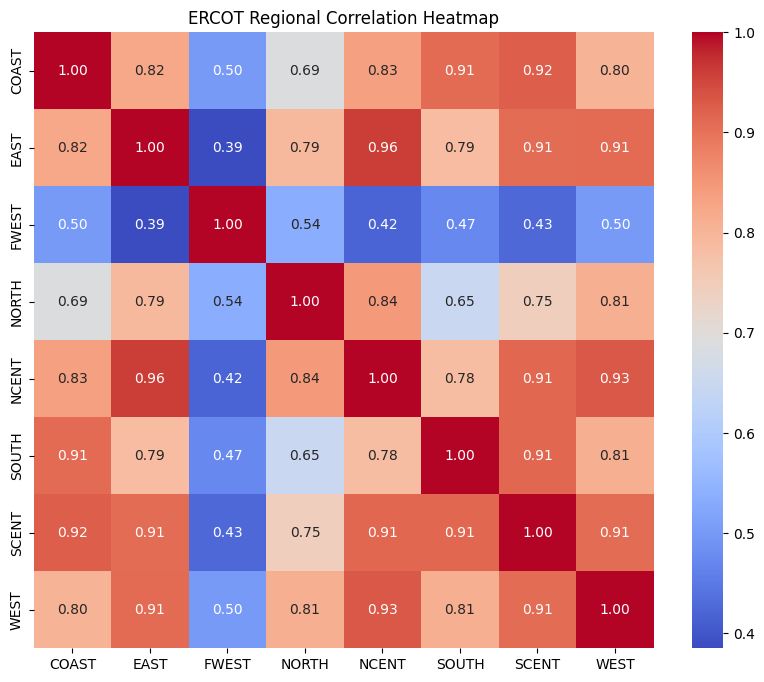

In [ ]:
import seaborn as sns

# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    regional_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("ERCOT Regional Correlation Heatmap")
plt.show()

In [ ]:
import networkx as nx

# Create graph
G = nx.Graph()

# Add nodes
for region in regions:
    G.add_node(region)

# Add edges for strong correlations
threshold = 0.90

for i in regions:
    for j in regions:
        if i != j:
            corr_value = regional_corr.loc[i, j]

            if corr_value > threshold:
                G.add_edge(i, j, weight=corr_value)

print("Nodes:", G.nodes())
print("Edges:", G.edges(data=True))

Nodes: ['COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH', 'SCENT', 'WEST']
Edges: [('COAST', 'SOUTH', {'weight': np.float64(0.9092611464698378)}), ('COAST', 'SCENT', {'weight': np.float64(0.9248561344403687)}), ('EAST', 'NCENT', {'weight': np.float64(0.9591858961535045)}), ('EAST', 'SCENT', {'weight': np.float64(0.9072156627364582)}), ('EAST', 'WEST', {'weight': np.float64(0.9095641834172021)}), ('NCENT', 'SCENT', {'weight': np.float64(0.9137216692696756)}), ('NCENT', 'WEST', {'weight': np.float64(0.932019097727019)}), ('SOUTH', 'SCENT', {'weight': np.float64(0.9145290814834458)}), ('SCENT', 'WEST', {'weight': np.float64(0.9083168416372364)})]


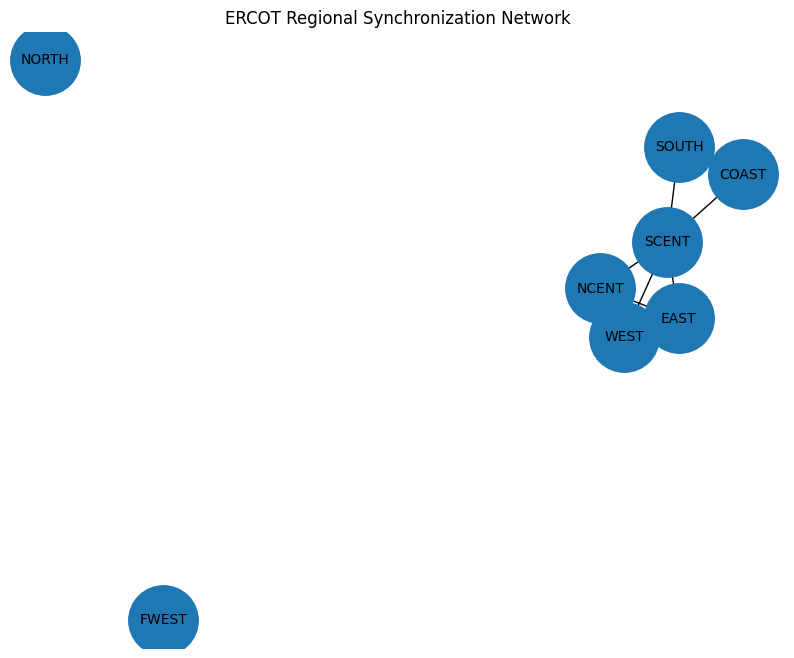

In [ ]:
# Plot Network
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=10
)

plt.title("ERCOT Regional Synchronization Network")
plt.axis('off')

plt.show()


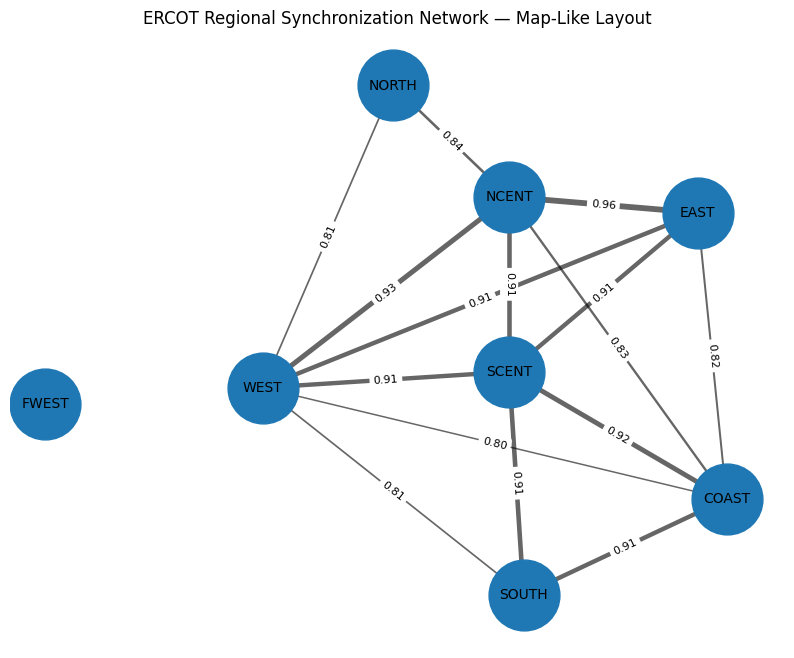

In [ ]:
# 10.6 Better ERCOT Regional Network Views

import networkx as nx
import matplotlib.pyplot as plt

# Approximate ERCOT weather-zone map positions
# These are not exact GIS boundaries — just a readable Texas-like layout.
ercot_pos = {
    'FWEST': (-3.2, 0.0),
    'WEST': (-1.7, 0.1),
    'NORTH': (-0.8, 2.0),
    'NCENT': (0.0, 1.3),
    'EAST': (1.3, 1.2),
    'SCENT': (0.0, 0.2),
    'SOUTH': (0.1, -1.2),
    'COAST': (1.5, -0.6)
}

# Build weighted correlation network
G = nx.Graph()

for region in regions:
    G.add_node(region)

threshold = 0.80  # lower than 0.90 so the network is more informative

for i in regions:
    for j in regions:
        if i < j:
            corr_value = regional_corr.loc[i, j]
            if corr_value >= threshold:
                G.add_edge(i, j, weight=corr_value)

# Edge widths based on correlation strength
edge_widths = [
    (G[u][v]['weight'] - threshold) * 20 + 1
    for u, v in G.edges()
]

plt.figure(figsize=(10,8))

nx.draw_networkx_nodes(
    G,
    ercot_pos,
    node_size=2600
)

nx.draw_networkx_labels(
    G,
    ercot_pos,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    ercot_pos,
    width=edge_widths,
    alpha=0.6
)

edge_labels = {
    (u, v): f"{G[u][v]['weight']:.2f}"
    for u, v in G.edges()
}

nx.draw_networkx_edge_labels(
    G,
    ercot_pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("ERCOT Regional Synchronization Network — Map-Like Layout")
plt.axis("off")
plt.show()

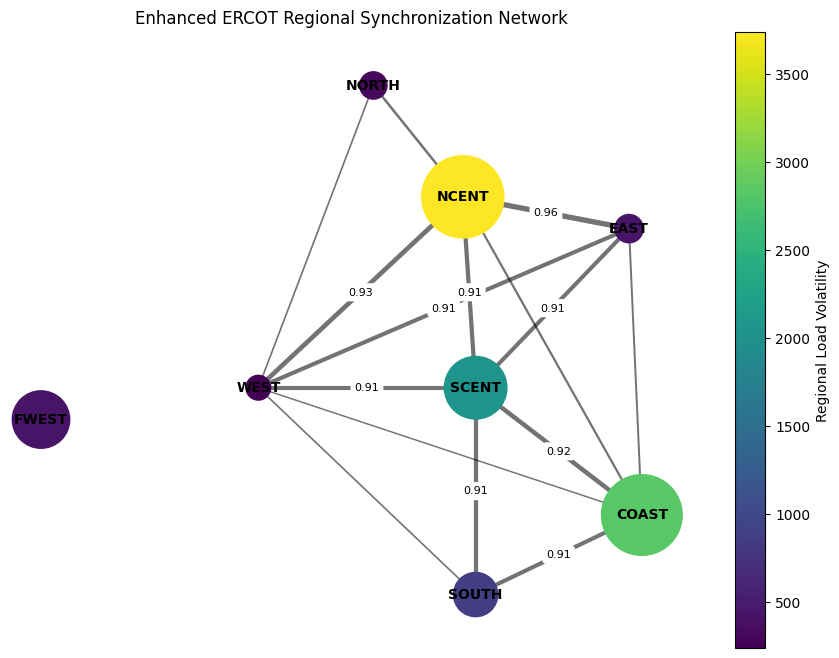

In [ ]:
# 10.3 Enhanced ERCOT Regional Network

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

regions = [
    'COAST', 'EAST', 'FWEST', 'NORTH',
    'NCENT', 'SOUTH', 'SCENT', 'WEST'
]

regional_data = merged[regions]
regional_corr = regional_data.corr()

# Approximate Texas-like ERCOT weather-zone positions
ercot_pos = {
    'FWEST': (-3.2, 0.0),
    'WEST': (-1.5, 0.2),
    'NORTH': (-0.6, 2.1),
    'NCENT': (0.1, 1.4),
    'EAST': (1.4, 1.2),
    'SCENT': (0.2, 0.2),
    'SOUTH': (0.2, -1.1),
    'COAST': (1.5, -0.6)
}

# Build graph
threshold = 0.80
G = nx.Graph()

for region in regions:
    G.add_node(region)

for i in regions:
    for j in regions:
        if i < j:
            corr = regional_corr.loc[i, j]
            if corr >= threshold:
                G.add_edge(i, j, weight=corr)

# Node size = average load
avg_load = regional_data.mean()
node_sizes = [avg_load[node] / avg_load.max() * 3500 for node in G.nodes()]

# Node color = volatility
volatility = regional_data.std()
node_colors = [volatility[node] for node in G.nodes()]

# Edge width = correlation strength
edge_widths = [
    (G[u][v]['weight'] - threshold) * 18 + 1
    for u, v in G.edges()
]

plt.figure(figsize=(11, 8))

nodes = nx.draw_networkx_nodes(
    G,
    ercot_pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap='viridis'
)

nx.draw_networkx_labels(
    G,
    ercot_pos,
    font_size=10,
    font_weight='bold'
)

nx.draw_networkx_edges(
    G,
    ercot_pos,
    width=edge_widths,
    alpha=0.55
)

edge_labels = {
    (u, v): f"{G[u][v]['weight']:.2f}"
    for u, v in G.edges()
    if G[u][v]['weight'] >= 0.90
}

nx.draw_networkx_edge_labels(
    G,
    ercot_pos,
    edge_labels=edge_labels,
    font_size=8,
    rotate=False
)

plt.colorbar(nodes, label='Regional Load Volatility')
plt.title('Enhanced ERCOT Regional Synchronization Network')
plt.axis('off')
plt.show()

In [ ]:
0